In [ ]:
#IMPORTING TOOLS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk

In [ ]:
#importing Data/creating df

df = pd.read_csv('../data/raw/state_of_data_survey_2024.csv')

In [ ]:
df.columns

Index(['0.a_token', '0.d_data/hora_envio', '1.a_idade', '1.a.1_faixa_idade',
       '1.b_genero', '1.c_cor/raca/etnia', '1.d_pcd',
       '1.e_experiencia_profissional_prejudicada',
       '1.e.1_Não acredito que minha experiência profissional seja afetada',
       '1.e.2_Sim, devido a minha Cor/Raça/Etnia',
       ...
       '8.d.3_Entrando em contato com os times de negócio para definição do problema, identificar a solução e apresentação de resultados.',
       '8.d.4_Desenvolvendo modelos de Machine Learning com o objetivo de colocar em produção em sistemas (produtos de dados).',
       '8.d.5_Colocando modelos em produção, criando os pipelines de dados, APIs de consumo e monitoramento.',
       '8.d.6_Cuidando da manutenção de modelos de Machine Learning já em produção, atuando no monitoramento, ajustes e refatoração quando necessário.',
       '8.d.7_Realizando construções de dashboards em ferramentas de BI como PowerBI, Tableau, Looker, Qlik, etc.',
       '8.d.8_Utilizando ferra

In [ ]:
#Selecting the target
list(df.columns)
df['2.h_faixa_salarial'].value_counts().sort_values()

2.h_faixa_salarial
Menos de R$ 1.000/mês                 33
Acima de R$ 40.001/mês               104
de R$ 1.001/mês a R$ 2.000/mês       155
de R$ 30.001/mês a R$ 40.000/mês     158
de R$ 25.001/mês a R$ 30.000/mês     159
de R$ 2.001/mês a R$ 3.000/mês       237
de R$ 20.001/mês a R$ 25.000/mês     246
de R$ 3.001/mês a R$ 4.000/mês       270
de R$ 16.001/mês a R$ 20.000/mês     456
de R$ 4.001/mês a R$ 6.000/mês       593
de R$ 6.001/mês a R$ 8.000/mês       656
de R$ 12.001/mês a R$ 16.000/mês     716
de R$ 8.001/mês a R$ 12.000/mês     1080
Name: count, dtype: int64

In [ ]:
#modifying the categories of the target and removing the NaN's
novas_categorias = {
    'de R$ 8.001/mês a R$ 12.000/mês': 'de R$ 8.001/mês a R$ 12.000/mês',
    'de R$ 12.001/mês a R$ 16.000/mês': 'de R$ 12.001/mês a R$ 20.000/mês',
    'de R$ 6.001/mês a R$ 8.000/mês': 'de R$ 6.001/mês a R$ 8.000/mês',
    'de R$ 4.001/mês a R$ 6.000/mês': 'de 3.001/mês a R$ 6.000/mês',
    'de R$ 16.001/mês a R$ 20.000/mês': 'de R$ 12.001/mês a R$ 20.000/mês',
    'de R$ 3.001/mês a R$ 4.000/mês': 'de 3.001/mês a R$ 6.000/mês',
    'de R$ 20.001/mês a R$ 25.000/mês': 'acima de R$ 20.000/mês',
    'de R$ 2.001/mês a R$ 3.000/mês': 'até R$ 3.000/mês',
    'de R$ 25.001/mês a R$ 30.000/mês': 'acima de R$ 20.000/mês',
    'de R$ 30.001/mês a R$ 40.000/mês': 'acima de R$ 20.000/mês',
    'de R$ 1.001/mês a R$ 2.000/mês': 'até R$ 3.000/mês',
    'Acima de R$ 40.001/mês': 'acima de R$ 20.000/mês',
    'Menos de R$ 1.000/mês': 'até R$ 3.000/mês'
}

df['categorias_target'] = df['2.h_faixa_salarial'].map(novas_categorias)


C:\Users\Ian Guilherme Dev\AppData\Local\Temp\ipykernel_7696\379486840.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['categorias_target'] = df['2.h_faixa_salarial'].map(novas_categorias)


In [ ]:
#rapida limpeza no df
remover = ['Vivo fora do Brasil e trabalho para empresa de fora do Brasil',
                          'Desempregado e não estou buscando recolocação']

df = df[~df['2.a_situação_de_trabalho'].isin(remover)]
df = df[df['categorias_target'].notna()]

In [ ]:
#correcting the order of the targets
from pandas import CategoricalDtype
categorias = CategoricalDtype(categories=[
    'até R$ 3.000/mês',           
    'de 3.001/mês a R$ 6.000/mês',      
    'de R$ 6.001/mês a R$ 8.000/mês',      
    'de R$ 8.001/mês a R$ 12.000/mês',     
    'de R$ 12.001/mês a R$ 20.000/mês',    
    'acima de R$ 20.000/mês'      
], ordered=True)

df['categorias_target'] = df['categorias_target'].astype(categorias)



<Axes: ylabel='categorias_target'>

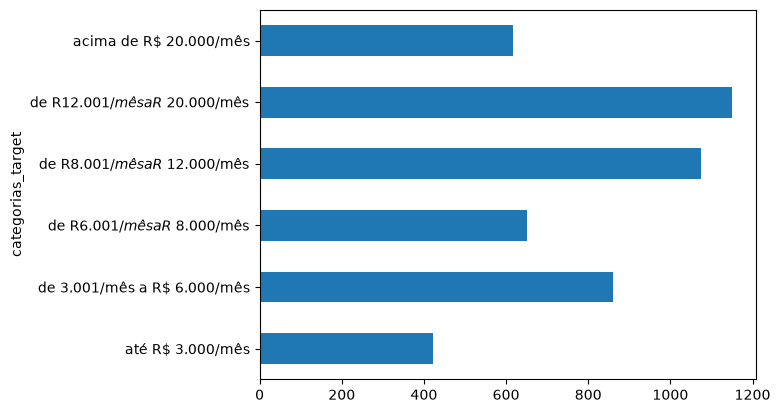

In [ ]:
df['categorias_target'].value_counts().sort_index().plot(kind='barh', )

In [ ]:
#selecting the features
selecionado = [
    '1.a_idade',
    '1.i.1_uf_onde_mora',
    '1.l_nivel_de_ensino', 
    '1.m_área_de_formação',
    '2.a_situação_de_trabalho',
    '2.b_setor',
    '2.f_cargo_atual',
    '2.g_nivel',   
    '2.j_tempo_de_experiencia_em_ti',
    '4.d.14_JavaScript',                                      
    '4.d.6_Java',
    '4.d.2_R',                                                
    '4.d.3_Python',                                          
    '4.d.1_SQL',
    '4.g.2_Oracle',           
    '4.g.1_MySQL',           
    '4.g.22_Google BigQuery', 
    '4.g.3_SQL SERVER',       
    '4.g.27_Databricks',      
    '4.g.12_PostgreSQL',
    '4.h.6_Servidores On Premise/Não utilizamos Cloud',
    '4.h.2_Google Cloud (GCP)',
    '4.h.3_Azure (Microsoft)',
    '4.h.1_Amazon Web Services (AWS)',
    'categorias_target'
]

df_tratado = (df[selecionado]
              .rename(columns={
                '1.a_idade': 'idade', 
                '1.i.1_uf_onde_mora': 'uf_onde_mora',
                '1.l_nivel_de_ensino': 'nivel_de_ensino', 
                '1.m_área_de_formação': 'area_formacao',
                '2.a_situação_de_trabalho': 'situacao_trabalho',
                '2.b_setor': 'setor',
                '2.f_cargo_atual': 'cargo_atual',
                '2.g_nivel': 'nivel_senioridade',   
                '2.j_tempo_de_experiencia_em_ti': 'tempo_experiencia',
                '4.d.14_JavaScript': 'JS',                                      
                '4.d.6_Java': 'Java',
                '4.d.2_R': 'R',                                                
                '4.d.3_Python': 'Python',                                          
                '4.d.1_SQL': 'SQL',
                '4.g.2_Oracle': 'Oracle',           
                '4.g.1_MySQL': 'MySQL',           
                '4.g.22_Google BigQuery': 'Google_BigQuery', 
                '4.g.3_SQL SERVER': 'SQL_Server',       
                '4.g.27_Databricks': 'Databricks',      
                '4.g.12_PostgreSQL': 'PostgreSQL',
                '4.h.6_Servidores On Premise/Não utilizamos Cloud': 'nao_utilizamos_cloud',
                '4.h.2_Google Cloud (GCP)': 'Google_cloud',
                '4.h.3_Azure (Microsoft)': 'Azure',
                '4.h.1_Amazon Web Services (AWS)': 'AWS'
                   
})) 

df_tratado

,idade,uf_onde_mora,nivel_de_ensino,area_formacao,situacao_trabalho,setor,cargo_atual,nivel_senioridade,tempo_experiencia,JS,...,MySQL,Google_BigQuery,SQL_Server,Databricks,PostgreSQL,nao_utilizamos_cloud,Google_cloud,Azure,AWS,categorias_target
0,18,RS,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Estagiário,Marketing,Analista de Dados/Data Analyst,Júnior,de 1 a 2 anos,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,até R$ 3.000/mês
1,18,SC,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Estagiário,Finanças ou Bancos,Analista de BI/BI Analyst,Júnior,Menos de 1 ano,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,até R$ 3.000/mês
2,18,SP,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Empregado (CLT),Indústria,Outra Opção,Júnior,Não tive experiência na área de TI/Engenharia ...,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,até R$ 3.000/mês
3,18,SP,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Estagiário,Tecnologia/Fábrica de Software,Analista de Dados/Data Analyst,Júnior,Não tive experiência na área de TI/Engenharia ...,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,até R$ 3.000/mês
4,18,SP,Estudante de Graduação,Computação / Engenharia de Software / Sistemas...,Estagiário,Tecnologia/Fábrica de Software,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,Menos de 1 ano,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,até R$ 3.000/mês
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5210,64,RJ,Pós-graduação,Outras Engenharias (não incluir engenharia de ...,Empregado (CLT),Setor de Energia,Engenheiro de Dados/Data Engineer/Data Architect,Sênior,de 7 a 10 anos,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,acima de R$ 20.000/mês
5211,66,MG,Pós-graduação,Economia/ Administração / Contabilidade / Fina...,Empreendedor ou Empregado (CNPJ),Área da Saúde,NaN,NaN,de 1 a 2 anos,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,de R$ 12.001/mês a R$ 20.000/mês
5212,66,RS,Graduação/Bacharelado,Computação / Engenharia de Software / Sistemas...,Empreendedor ou Empregado (CNPJ),Área de Consultoria,NaN,NaN,Mais de 10 anos,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,acima de R$ 20.000/mês
5213,66,DF,Mestrado,Computação / Engenharia de Software / Sistemas...,Empreendedor ou Empregado (CNPJ),Tecnologia/Fábrica de Software,Cientista de Dados/Data Scientist,Sênior,Mais de 10 anos,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,de R$ 12.001/mês a R$ 20.000/mês


In [ ]:
#selecting the features x target in the full_dataset
X = df_tratado.drop(columns='categorias_target')
y = df_tratado['categorias_target'].copy()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state=42,
                                                    stratify=df_tratado['categorias_target'])

In [ ]:
#stratify works well
print(y_train.value_counts(normalize=True).sort_index())
print(y_test.value_counts(normalize=True).sort_index())

categorias_target
até R$ 3.000/mês                    0.088523
de 3.001/mês a R$ 6.000/mês         0.180117
de R$ 6.001/mês a R$ 8.000/mês      0.136275
de R$ 8.001/mês a R$ 12.000/mês     0.225077
de R$ 12.001/mês a R$ 20.000/mês    0.240994
acima de R$ 20.000/mês              0.129014
Name: proportion, dtype: float64
categorias_target
até R$ 3.000/mês                    0.088777
de 3.001/mês a R$ 6.000/mês         0.180067
de R$ 6.001/mês a R$ 8.000/mês      0.136516
de R$ 8.001/mês a R$ 12.000/mês     0.225293
de R$ 12.001/mês a R$ 20.000/mês    0.240369
acima de R$ 20.000/mês              0.128978
Name: proportion, dtype: float64


In [ ]:
X_train.columns

Index(['idade', 'uf_onde_mora', 'nivel_de_ensino', 'area_formacao',
       'situacao_trabalho', 'setor', 'cargo_atual', 'nivel_senioridade',
       'tempo_experiencia', 'JS', 'Java', 'R', 'Python', 'SQL', 'Oracle',
       'MySQL', 'Google_BigQuery', 'SQL_Server', 'Databricks', 'PostgreSQL',
       'nao_utilizamos_cloud', 'Google_cloud', 'Azure', 'AWS'],
      dtype='str')

In [ ]:
#spliting the features for each type
num_list = ['idade']

cat_ordinal_list = ['nivel_de_ensino',
                    'nivel_senioridade',
                    'tempo_experiencia']

cat_one_hot_list = ['uf_onde_mora', 
                     'area_formacao', 'situacao_trabalho',
                     'setor', 'cargo_atual']

bin_list = ['JS', 'Java', 'R', 'Python',
       'SQL', 'Oracle', 'MySQL', 'Google_BigQuery', 'SQL_Server', 'Databricks',
       'PostgreSQL', 'nao_utilizamos_cloud', 'Google_cloud', 'Azure', 'AWS']

In [ ]:
#Building the pipeline
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

num_pipeline = make_pipeline(StandardScaler())

cat_ord_pipeline = make_pipeline(SimpleImputer(strategy='constant',
                                               fill_value='Não Informado'),
                                 OrdinalEncoder(categories=[
                                        ['Prefiro não informar', 'Não tenho graduação formal',
                                        'Estudante de Graduação', 'Graduação/Bacharelado',
                                        'Pós-graduação', 'Mestrado', 'Doutorado ou Phd' ],
                                        ['Não Informado', 'Júnior', 'Pleno', 'Sênior'],
                                        ['Não tive experiência na área de TI/Engenharia de Software antes de começar a trabalhar na área de dados',
                                        'Menos de 1 ano', 'de 1 a 2 anos','de 3 a 4 anos','de 5 a 6 anos','de 7 a 10 anos','Mais de 10 anos']]))
                                 

cat_one_hot_pipeline = make_pipeline(SimpleImputer(strategy='constant',
                                                   fill_value='Não Informado'),
                                     OneHotEncoder(handle_unknown='ignore',
                                                   sparse_output=False))
                                     

bin_pipeline = make_pipeline(SimpleImputer(strategy='constant',
                                           fill_value=0))


In [ ]:
#creating the ColumnTransformer
from sklearn.compose import ColumnTransformer

preprocessing = ColumnTransformer([
   ('numeric', num_pipeline, num_list), 
   ('ordinal_encoded', cat_ord_pipeline, cat_ordinal_list), 
   ('one_hot_encoded', cat_one_hot_pipeline, cat_one_hot_list), 
   ('bin', bin_pipeline, bin_list) 
])


In [ ]:
#creating the preprocessed X_train
X_preprocessed = pd.DataFrame(preprocessing.fit_transform(X_train),
                columns=preprocessing.get_feature_names_out(),
                index=X_train.index)

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

#o certo é passar o pipeline completo
baseline_model = make_pipeline(preprocessing, DummyClassifier(strategy='most_frequent'))
svc_model = make_pipeline(preprocessing, SVC(random_state=42))
rfc_model = make_pipeline(preprocessing, RandomForestClassifier(random_state=42))
lr_model = make_pipeline(preprocessing, LogisticRegression(random_state=42)) 

models = [baseline_model, svc_model, rfc_model, lr_model]

for idx, model in enumerate(models):
    cvs = cross_val_score(model,
                    X_train,
                    y_train,
                    scoring='f1_macro',
                    cv=3)
    print(f'''O modelo {type(model.steps[-1][1]).__name__},
          teve MÉDIA DE ACERTOS de {cvs.mean():.1%}
          e DESVIO PADRÃO de {cvs.std():.4%}''')

O modelo DummyClassifier,
          teve MÉDIA DE ACERTOS de 6.5%
          e DESVIO PADRÃO de 0.0097%
O modelo SVC,
          teve MÉDIA DE ACERTOS de 47.0%
          e DESVIO PADRÃO de 1.3538%
O modelo RandomForestClassifier,
          teve MÉDIA DE ACERTOS de 47.3%
          e DESVIO PADRÃO de 1.4600%


c:\Users\Ian Guilherme Dev\Desktop\projetos-pessoais\preditor-salario-ti\.venv ti-predict\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Ian Guilherme Dev\Desktop\projetos-pessoais\preditor-salario-ti\.venv ti-predict\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100)

O modelo LogisticRegression,
          teve MÉDIA DE ACERTOS de 49.2%
          e DESVIO PADRÃO de 1.4701%


c:\Users\Ian Guilherme Dev\Desktop\projetos-pessoais\preditor-salario-ti\.venv ti-predict\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


_Ao analisar os resultados, o módelo provisório favorito é o LogisticRegressor com:_

MÉDIA DE ACERTOS de 49.2% e DESVIO PADRÃO de 0.0147

In [ ]:
#adicionando class_weight para inverter o peso, ou seja, dados menos frequentes terão mais peso.
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

#o certo é passar o pipeline completo
baseline_model = make_pipeline(preprocessing, DummyClassifier(strategy='most_frequent'))
svc_model_bal = make_pipeline(preprocessing, SVC(random_state=42,
                                             class_weight='balanced'))
rfc_model_bal = make_pipeline(preprocessing, RandomForestClassifier(random_state=42,
                                                                class_weight='balanced'))
lr_model_bal = make_pipeline(preprocessing, LogisticRegression(random_state=42,
                                                           class_weight='balanced')) 

models = [baseline_model, svc_model, rfc_model, lr_model]

for idx, model in enumerate(models):
    cvs = cross_val_score(model,
                    X_train,
                    y_train,
                    scoring='f1_macro',
                    cv=3)
    print(f'''O modelo {type(model.steps[-1][1]).__name__},
          teve MÉDIA DE ACERTOS de {cvs.mean():.1%}
          e DESVIO PADRÃO de {cvs.std():.4%}''')

O modelo DummyClassifier,
          teve MÉDIA DE ACERTOS de 6.5%
          e DESVIO PADRÃO de 0.0097%
O modelo SVC,
          teve MÉDIA DE ACERTOS de 47.0%
          e DESVIO PADRÃO de 1.3538%
O modelo RandomForestClassifier,
          teve MÉDIA DE ACERTOS de 47.3%
          e DESVIO PADRÃO de 1.4600%


c:\Users\Ian Guilherme Dev\Desktop\projetos-pessoais\preditor-salario-ti\.venv ti-predict\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Ian Guilherme Dev\Desktop\projetos-pessoais\preditor-salario-ti\.venv ti-predict\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100)

O modelo LogisticRegression,
          teve MÉDIA DE ACERTOS de 49.2%
          e DESVIO PADRÃO de 1.4701%


c:\Users\Ian Guilherme Dev\Desktop\projetos-pessoais\preditor-salario-ti\.venv ti-predict\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


balanced ajudou modelos de árvore/margem, atrapalhou o linear

Por enquanto o modelo escolhido é o RandomForestClassifier com class_weight balanced

c:\Users\Ian Guilherme Dev\Desktop\projetos-pessoais\preditor-salario-ti\.venv ti-predict\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Ian Guilherme Dev\Desktop\projetos-pessoais\preditor-salario-ti\.venv ti-predict\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100)

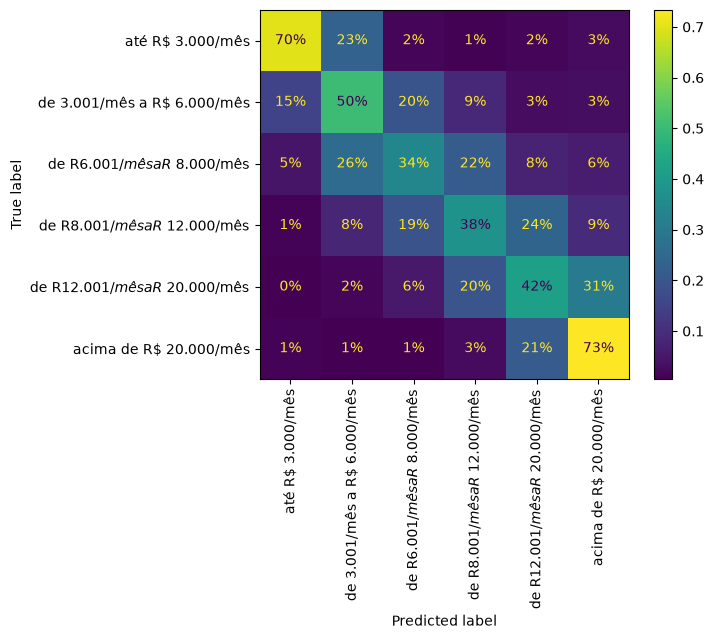

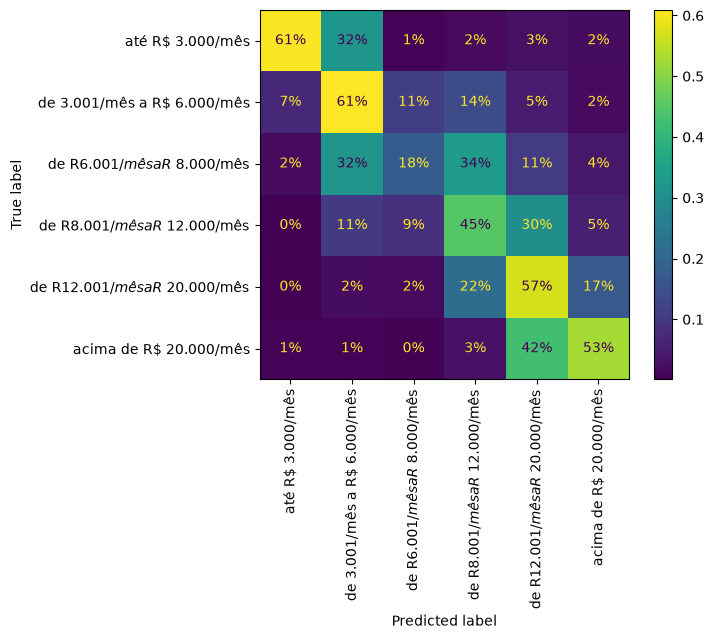

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import cross_val_predict

lr_bal_predicts = cross_val_predict(lr_model_bal,
                                 X_train,
                                 y_train,
                                 cv=3)

lr_predicts = cross_val_predict(lr_model,
                                 X_train,
                                 y_train,
                                 cv=3)

ConfusionMatrixDisplay.from_predictions(y_train, lr_bal_predicts,
                                        normalize='true',
                                        values_format='.0%',
                                        labels=list(y_train.sort_values().unique()),
                                        xticks_rotation='vertical')

ConfusionMatrixDisplay.from_predictions(y_train, lr_predicts,
                                        normalize='true',
                                        values_format='.0%',
                                        labels=list(y_train.sort_values().unique()),
                                        xticks_rotation='vertical')




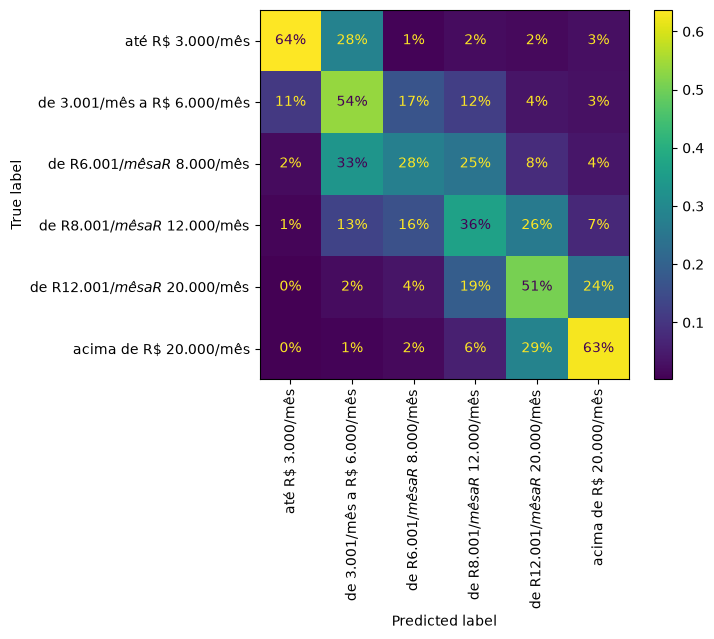

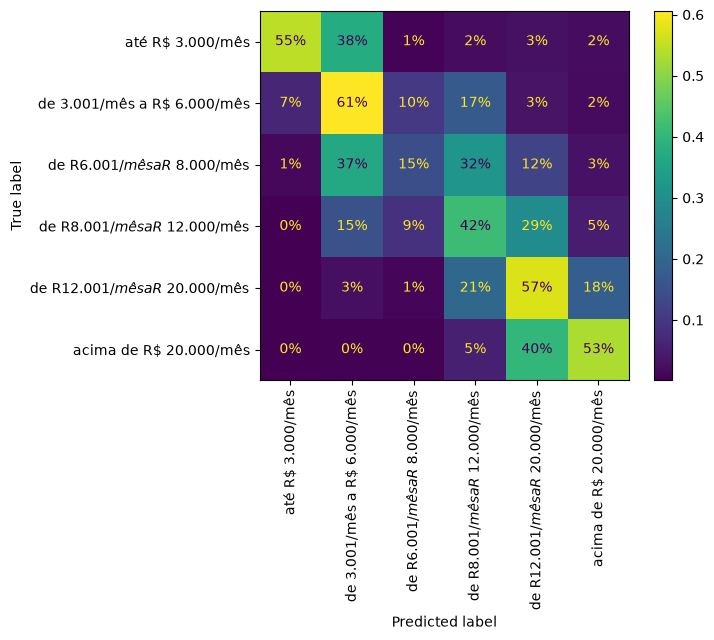

In [ ]:
rfc_bal_predicts = cross_val_predict(rfc_model_bal,
                                 X_train,
                                 y_train,
                                 cv=3)

rfc_predicts = cross_val_predict(rfc_model,
                                 X_train,
                                 y_train,
                                 cv=3)

ConfusionMatrixDisplay.from_predictions(y_train, rfc_bal_predicts,
                                        normalize='true',
                                        values_format='.0%',
                                        labels=list(y_train.sort_values().unique()),
                                        xticks_rotation='vertical')

ConfusionMatrixDisplay.from_predictions(y_train, rfc_predicts,
                                        normalize='true',
                                        values_format='.0%',
                                        labels=list(y_train.sort_values().unique()),
                                        xticks_rotation='vertical')

In [ ]:
from  sklearn.metrics import classification_report # faz uma classificação geral

predicts_list = {'LogReg' : lr_predicts,
                 'LogRegBal' : lr_bal_predicts,
                 'RandForClass' : rfc_predicts,
                 'RandForClassBal' : rfc_bal_predicts}


for name, predict in predicts_list.items():
    cl_rp = classification_report(y_true=y_train, y_pred=predict, labels=y_train.cat.categories)
    print(f'o modelo {name}, gerou: {cl_rp}')
    print('-' * 100)



o modelo LogReg, gerou:                                   precision    recall  f1-score   support

                até R$ 3.000/mês       0.76      0.61      0.67       317
     de 3.001/mês a R$ 6.000/mês       0.52      0.61      0.56       645
  de R$ 6.001/mês a R$ 8.000/mês       0.35      0.18      0.24       488
 de R$ 8.001/mês a R$ 12.000/mês       0.44      0.45      0.44       806
de R$ 12.001/mês a R$ 20.000/mês       0.48      0.57      0.52       863
          acima de R$ 20.000/mês       0.51      0.53      0.52       462

                        accuracy                           0.49      3581
                       macro avg       0.51      0.49      0.49      3581
                    weighted avg       0.49      0.49      0.49      3581

----------------------------------------------------------------------------------------------------
o modelo LogRegBal, gerou:                                   precision    recall  f1-score   support

                até R$ 3.000/m

In [ ]:
# escolha do modelo Logistic Regression Balanced

#aplicadno no Test Set
lr_model_bal.fit(X_train, y_train)
predicts_test = lr_model_bal.predict(X_test)

cl_rp_test = classification_report(y_true=y_test,
                                   y_pred=predicts_test,
                                   labels=y_test.cat.categories)

print(cl_rp_test)

                                  precision    recall  f1-score   support

                até R$ 3.000/mês       0.58      0.77      0.66       106
     de 3.001/mês a R$ 6.000/mês       0.50      0.49      0.50       215
  de R$ 6.001/mês a R$ 8.000/mês       0.29      0.31      0.30       163
 de R$ 8.001/mês a R$ 12.000/mês       0.49      0.36      0.42       269
de R$ 12.001/mês a R$ 20.000/mês       0.55      0.41      0.47       287
          acima de R$ 20.000/mês       0.48      0.79      0.60       154

                        accuracy                           0.48      1194
                       macro avg       0.48      0.52      0.49      1194
                    weighted avg       0.49      0.48      0.47      1194



c:\Users\Ian Guilherme Dev\Desktop\projetos-pessoais\preditor-salario-ti\.venv ti-predict\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


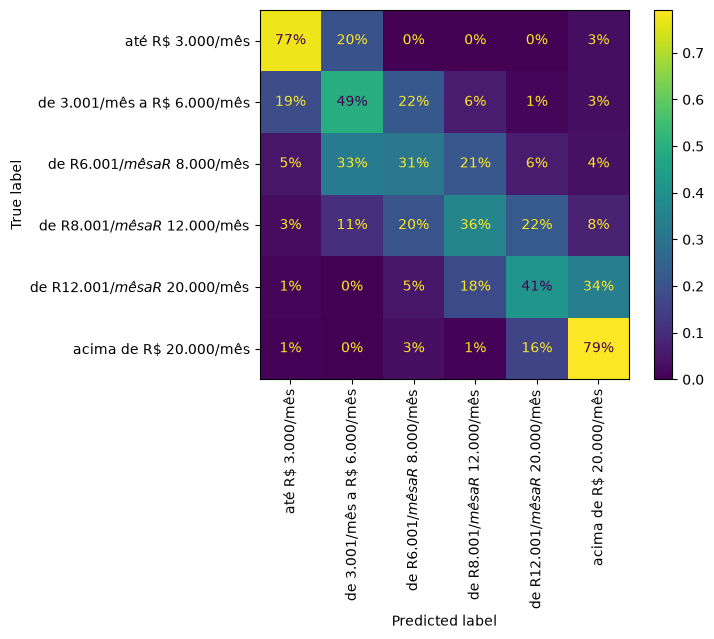

In [ ]:
cm = confusion_matrix(y_test, predicts_test)

ConfusionMatrixDisplay.from_predictions(y_true=y_test,
                                        y_pred=predicts_test,
                                        labels=y_test.cat.categories,
                                        normalize='true',
                                        values_format='.0%',
                                        xticks_rotation='vertical')

### CONCLUSÃO

_Como fechamento desse projeto, o modelo chegou em um limiar de f1-score, considerando macro avg, de 49% tanto no set de validação quanto no test-set, logo isso representa que o modelo generalizou muito bem, apesar de diferenças sutis em algumas faixas categóricas entre o modelo no test-set e no de validação_

- CONCLUSÕES FINAIS:
    - As faixas de 6.000 a 8000 e de 8.001 a 12.000 são o ponto fraco do modelo, mas a taxa de erro aponta principalmente para as classes vizinhas, pois as pessoas que ganham 7.900 e 8.100 tem quase o mesmo perfil, mas isso comprova que o modelo identificou e capturou a estrutura ordinal sobre as faixas salariais, pois os erros são majoritariamente em faixas vizinhas.
    - Os extremos foram muito beneficiados com o class-weight balanced ( mesmo que já fossem bons por conta de so terem uma classe vizinhas ).
    - O modelo Logistic Regressor Balanced foi o que apresentou melhor comportamento na validação com cross_validation entre os modelos avaliados, por isso foi escolhido como modelo final.
        - Fiz o teste com o modelo de RandomForestClassifier e ele se adaptou melhor ao test_set, mas escolher um modelo a partir do test_set é vazamento de dados, então o modelo foi escolhido categoricamente com base no test de validação.
    - Para esse modelo a acurácia em geral foi 48%, o que se aproximou bem do comportamento real do modelo, isso se da por conta dos dados estarem bem distribuidos, sem heavy_tail e com desbalanceamento moderado. Isso é consequencia de uma decisão no inicio do projeto (reduzir de 13 categorias para apenas 6 distribuindo de forma mais homogenea os dados ).

- FECHAMENTO COM V1: 
    - O modelo v1 (de Regressão ) foi pensado como problema de regressão, mas ao analisar o target ficou claro que na verdade se tratava de um problema de classificação. Ao prosseguir com a analise, os dados comprovaram essa suspeita e no momento que identifiquei uma barreira para um modelo de regressão ( prever um valor contínuo sobre faixas discretizadas, gerando um teto estrutural para o modelo ) optei por estudar como um modelo de classificação opera e aplicar esses conhecimentos nesse projeto, resultando em um modelo com aproximadamente 48% de acurrácia e 49% de f1_score com macro avg, com desempenho estável entre validação e teste.
    